# 00 | Sample Selection

In [30]:
pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.2
aiohttp                                  3.13.5
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

## Section 1 - Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
!pip install astroquery
from astroquery.sdss import SDSS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.7 MB/s eta 0:00:00


## Querying SDSS via astroquery

In [3]:
query = """
SELECT TOP 3000
  p.objid, p.ra, p.dec, p.petroRad_r, s.z, s.class, p.modelMag_u, p.modelMag_g, p.modelMag_r, p.modelMag_i, p.modelMag_z, s.snMedian
FROM PhotoObj AS p
JOIN SpecObj AS s ON p.objid = s.bestObjID
WHERE p.clean = 1 AND s.class = 'GALAXY' AND s.z BETWEEN 0.02 AND 0.25
"""

result = SDSS.query_sql(query)
result

objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,snMedian
uint64,float64,float64,float64,float64,str6,float64,float64,float64,float64,float64,float64
1237648720142008515,145.821638182128,-0.846601885046273,5.089256,0.06770252,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,10.20291
1237648720142008580,145.818101273901,-0.878973095843891,5.040677,0.2045784,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,11.13883
1237648720142073942,145.853157594108,-0.997063559085189,3.825139,0.1448017,GALAXY,20.61629,18.63789,17.54523,17.09494,16.7594,13.57714
1237648720142073959,145.892309469118,-1.02264988945927,4.531637,0.153699,GALAXY,20.39159,18.22442,17.0139,16.50938,16.11972,16.28147
1237648720145481973,153.76244236045,-0.997307833184848,3.391995,0.09821908,GALAXY,20.57385,18.64201,17.66163,17.22909,16.88417,11.06976
1237648720145547522,153.898219215873,-1.00150629900931,8.192672,0.08365821,GALAXY,19.16637,17.45534,16.65019,16.24938,15.93866,14.13568
1237648720145547565,153.831485337094,-1.0094143653045,5.452964,0.1642963,GALAXY,19.67307,18.35104,17.5455,17.06732,16.75602,9.030925
1237648720145547571,153.850132893032,-0.989024883704266,7.099805,0.2016057,GALAXY,20.63587,18.50025,17.35936,16.76465,16.31428,6.994599
1237648720145613050,153.965613866489,-0.974097497777007,5.108194,0.0702217,GALAXY,18.73285,17.45038,16.85139,16.46405,16.21558,16.49333


In [4]:
df = result.to_pandas()
df.head()

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,snMedian
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,10.20291
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,11.13883
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,13.57714
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,16.28147
4,1237648720145481973,153.762442,-0.997308,3.391995,0.098219,GALAXY,20.57385,18.64201,17.66163,17.22909,16.88417,11.06976


In [5]:
df

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,snMedian
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,10.202910
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,11.138830
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,13.577140
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,16.281470
4,1237648720145481973,153.762442,-0.997308,3.391995,0.098219,GALAXY,20.57385,18.64201,17.66163,17.22909,16.88417,11.069760
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1237657630067064939,188.650746,52.997370,4.636442,0.077760,GALAXY,19.26814,17.34073,16.43362,16.01825,15.72160,18.995350
2996,1237657630067064960,188.688915,52.992083,3.981185,0.078785,GALAXY,19.92838,18.51733,17.79325,17.36053,17.14342,9.095428
2997,1237657630585585808,130.370024,38.403809,15.107170,0.115879,GALAXY,18.64595,16.81442,15.83316,15.36183,14.97925,22.181140
2998,1237657630585651280,130.589710,38.508893,2.837538,0.153818,GALAXY,20.36216,18.43305,17.42063,16.99497,16.66508,18.529770


## Quality Cuts

In [6]:
cuts = (df['snMedian'] > 10) & (df['petroRad_r'] > 3) & (df['modelMag_r'] < 17.77)
df_clean = df[cuts]

In [7]:
print(f"Before cuts: {len(df)}")
print(f"After cuts: {len(df_clean)}")
print(f"Fraction of targets retained: {len(df_clean)/len(df):.2f}")

Before cuts: 3000
After cuts: 1747
Fraction of targets retained: 0.58


## Plotting

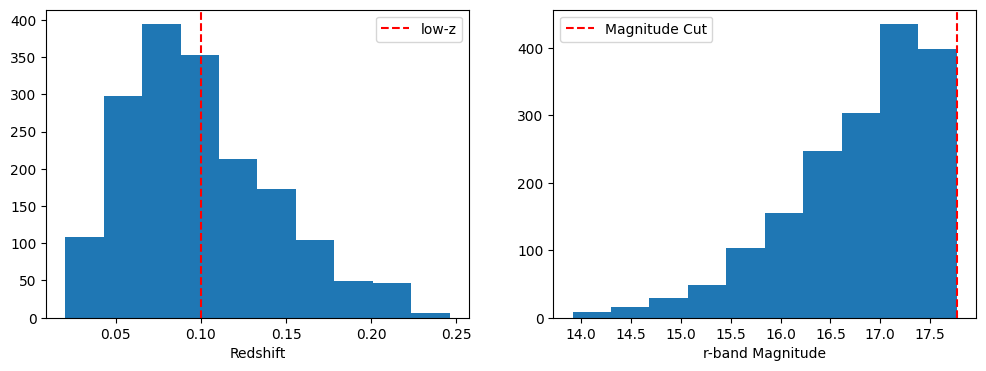

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(df_clean['z'])
axes[0].set_xlabel('Redshift')
axes[0].axvline(0.1, color='red', linestyle='--', label='low-z')
axes[0].legend()

axes[1].hist(df_clean['modelMag_r'])
axes[1].set_xlabel('r-band Magnitude')
axes[1].axvline(17.77, color='red', linestyle='--', label='Magnitude Cut')
axes[1].legend()


In [15]:
df_clean['low_z'] = df_clean['z'] < 0.1
df_clean

/tmp/ipykernel_1997/1020378291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['low_z'] = df_clean['z'] < 0.1


,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,snMedian,low_z
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,10.20291,True
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,11.13883,False
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,13.57714,False
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,16.28147,False
4,1237648720145481973,153.762442,-0.997308,3.391995,0.098219,GALAXY,20.57385,18.64201,17.66163,17.22909,16.88417,11.06976,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,1237657630064771164,180.024895,52.856926,7.255751,0.066559,GALAXY,17.00500,15.86378,15.29716,14.88341,14.74320,27.81766,True
2993,1237657630064836760,180.184383,52.915778,4.151716,0.062125,GALAXY,18.83415,17.68426,17.19932,16.86122,16.67442,15.46933,True
2994,1237657630064967752,180.694067,53.037893,6.406927,0.062437,GALAXY,18.59546,17.32973,16.74337,16.38386,16.18288,12.43912,True
2995,1237657630067064939,188.650746,52.997370,4.636442,0.077760,GALAXY,19.26814,17.34073,16.43362,16.01825,15.72160,18.99535,True


In [18]:
df_clean = df_clean.reset_index(drop=True)
df_clean

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,snMedian,low_z
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,10.20291,True
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,11.13883,False
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,13.57714,False
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,16.28147,False
4,1237648720145481973,153.762442,-0.997308,3.391995,0.098219,GALAXY,20.57385,18.64201,17.66163,17.22909,16.88417,11.06976,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1742,1237657630064771164,180.024895,52.856926,7.255751,0.066559,GALAXY,17.00500,15.86378,15.29716,14.88341,14.74320,27.81766,True
1743,1237657630064836760,180.184383,52.915778,4.151716,0.062125,GALAXY,18.83415,17.68426,17.19932,16.86122,16.67442,15.46933,True
1744,1237657630064967752,180.694067,53.037893,6.406927,0.062437,GALAXY,18.59546,17.32973,16.74337,16.38386,16.18288,12.43912,True
1745,1237657630067064939,188.650746,52.997370,4.636442,0.077760,GALAXY,19.26814,17.34073,16.43362,16.01825,15.72160,18.99535,True


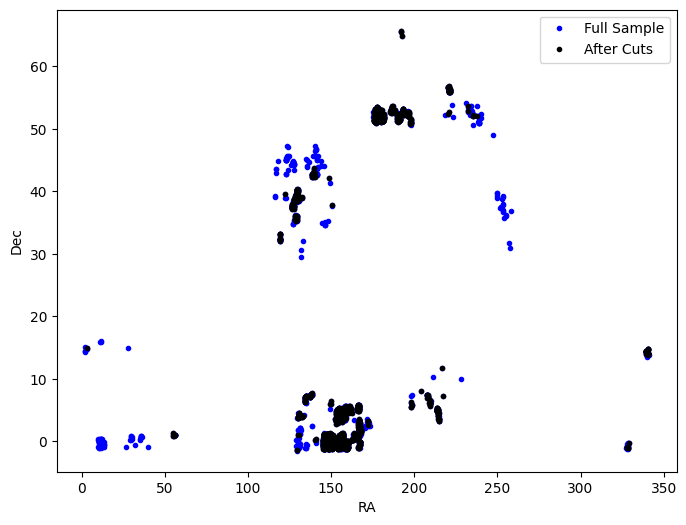

In [24]:
plt.figure(figsize=(8,6))
plt.plot(df['ra'], df['dec'], 'b.', label='Full Sample')

plt.plot(df_clean['ra'], df_clean['dec'], 'k.', label="After Cuts")
plt.xlabel('RA')
plt.ylabel('Dec')
plt.legend()

### Export panda dataframe to csv

In [26]:
df_clean.to_csv("galaxy_sample.csv", index=False)